# Phase 1: Single Image Analysis - Verification Notebook

This notebook verifies the Phase 1 implementation of the pickleball pose analyzer step by step.

## Overview

Phase 1 focuses on:
1. ✅ Loading and initializing the SAM 3D Body model
2. ✅ Processing individual pickleball pose images
3. ✅ Extracting 3D keypoints and pose data
4. ✅ Scoring each position (preparation, contact, finish)

## Key APIs

- **`load_sam3d_model()`** - Initialize SAM 3D Body estimator
- **`process_single_image()`** - Process one image and extract pose data
- **`process_three_positions()`** - Process three images at once
- **`extract_keypoints()`** - Extract specific keypoints by name
- **`score_preparation_position()`** - Score preparation pose
- **`score_contact_position()`** - Score contact pose
- **`score_finish_position()`** - Score finish pose

## Step 1: Setup and Imports

Import the pickleball_pose_analyzer module and verify it's working.

In [1]:
import sys
import os
from pathlib import Path

# Setup matplotlib for inline plotting
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
%matplotlib inline

# Add project root to path
project_root = Path().resolve().parent.parent
sys.path.insert(0, str(project_root / 'libraries' / 'src'))

# Import pickleball_pose_analyzer
from pickleball_pose_analyzer import (
    # Model loading
    load_sam3d_model,
    # Image processing
    process_single_image,
    process_three_positions,
    # Keypoint extraction
    extract_keypoints,
    calculate_body_center,
    # Scoring
    score_preparation_position,
    score_contact_position,
    score_finish_position,
    calculate_3d_angle,
    # Data structures
    PICKLEBALL_KEYPOINTS,
    KEYPOINT_NAMES_TO_INDICES,
    PoseData,
    PositionScore,
)

print("✅ Successfully imported pickleball_pose_analyzer")
print(f"Available keypoints: {list(PICKLEBALL_KEYPOINTS.keys())}")

✅ Successfully imported pickleball_pose_analyzer
Available keypoints: ['left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist', 'neck', 'left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_ankle', 'right_ankle', 'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear']


/Users/chang/Documents/dev/git/ml/coachKata/models/sam-3d-body/sam_3d_body/models/heads/mhr_head.py:31: UserWarning: Momentum is not enabled
  warnings.warn("Momentum is not enabled")


## Step 2: Load SAM 3D Body Model

**Key API: `load_sam3d_model()`**

This function supports loading from:
- **HuggingFace** (default): Downloads and caches the model in `~/.cache/huggingface/hub/`
- **Local checkpoint**: Load from a local checkpoint file or directory

**Local Checkpoint Structure:**
```
checkpoints/sam-3d-body-dinov3/
  ├── model.ckpt              # Main model checkpoint
  ├── assets/
  │   └── mhr_model.pt       # MHR (Momentum Human Rig) model
  └── model_config.yaml       # Model configuration (auto-detected)
```

**Parameters:**
- `checkpoint_path`: Local path to checkpoint file (e.g., `"model.ckpt"`) or directory containing `"model.ckpt"`. If provided, loads from local checkpoint instead of HuggingFace.
- `hf_repo_id`: HuggingFace repository ID (default: "facebook/sam-3d-body-dinov3", used if `checkpoint_path` is None)
- `device`: "auto", "cuda", or "cpu" (default: "auto")
- `use_detector`: Whether to use human detector (default: True)
    * Needed to create a bounding box around the human; especially if there are multiple humans
- `use_fov_estimator`: Whether to use FOV estimator (default: True)
    * camera focal length ~= zoom level --> important for 3D reconstruction; see my_docs/api_notes.md

In [2]:
# Option 1: Load from HuggingFace (default)
"""
print("=" * 60)
print("Option 1: Loading from HuggingFace")
print("=" * 60)
print("This may take a few minutes on first run (downloading from HuggingFace)")

estimator, config = load_sam3d_model(
    hf_repo_id="facebook/sam-3d-body-dinov3",
    device="auto",  # Auto-detect CUDA if available
    use_detector=True,
    use_fov_estimator=True,
)

print(f"✅ Model loaded successfully!")
print(f"   Source: HuggingFace ({config.get('hf_repo_id', 'unknown')})")
print(f"   Device: {config.get('device', 'unknown')}")
print(f"   Has detector: {config.get('has_detector', False)}")
print(f"   Has FOV estimator: {config.get('has_fov_estimator', False)}")
print()
"""
# Option 2: Load from local checkpoint (if available)
print("=" * 60)
print("Option 2: Loading from Local Checkpoint")
print("=" * 60)

# Example: Load from a checkpoint directory or file
# Option A: Specify checkpoint directory (function will look for model.ckpt inside)
checkpoint_path = project_root / 'models' / 'sam-3d-body' / 'checkpoints' / 'sam-3d-body-dinov3'

# Option B: Specify checkpoint file directly (uncomment to use):
# checkpoint_path = project_root / 'models' / 'sam-3d-body' / 'checkpoints' / 'sam-3d-body-dinov3' / 'model.ckpt'

# Option C: Use absolute path (uncomment and adjust if needed):
# checkpoint_path = Path("/Users/chang/Documents/dev/git/ml/coachKata/models/sam-3d-body/checkpoints/sam-3d-body-dinov3")

# Check if checkpoint exists (as Path object)
if checkpoint_path.exists():
    print(f"Found checkpoint at: {checkpoint_path}")
    estimator, config = load_sam3d_model(
        checkpoint_path=str(checkpoint_path),  # Convert to string for the function
        device="auto",
        use_detector=False, #disabling both save about 5sec per inference
        use_fov_estimator=False,
    )
    
    print(f"✅ Model loaded successfully!")
    print(f"   Source: Local checkpoint ({config.get('checkpoint_path', 'unknown')})")
    print(f"   Device: {config.get('device', 'unknown')}")
    print(f"   Has detector: {config.get('has_detector', False)}")
    print(f"   Has FOV estimator: {config.get('has_fov_estimator', False)}")
else:
    print(f"⚠️  Local checkpoint not found at: {checkpoint_path}")
    print("   Please download checkpoints or use Option 1 (HuggingFace) instead.")
    print()
    print("   To download checkpoints from HuggingFace:")
    print("   hf download facebook/sam-3d-body-dinov3 --local-dir models/sam-3d-body/checkpoints/sam-3d-body-dinov3")


Option 2: Loading from Local Checkpoint
Found checkpoint at: /Users/chang/Documents/dev/git/ml/coachKata/models/sam-3d-body/checkpoints/sam-3d-body-dinov3
CUDA not available, using CPU
Using device: cpu
Loading SAM 3D Body model from local checkpoint: /Users/chang/Documents/dev/git/ml/coachKata/models/sam-3d-body/checkpoints/sam-3d-body-dinov3
Loading SAM 3D Body model...


Using cache found in /Users/chang/.cache/torch/hub/facebookresearch_dinov3_main
Ignored kwargs: {'drop_path': 0.1}
The model and loaded state dict do not match exactly

missing keys in source state_dict: backbone.encoder.mask_token, head_pose.hand_pose_comps_ori, head_pose.mhr.face_expressions_model.shape_vectors, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_indices, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_weight, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.2.weight, head_pose.mhr.character_torch.skeleton.joint_translation_offsets, head_pose.mhr.character_torch.skeleton.joint_prerotations, head_pose.mhr.character_torch.skeleton.pmi, head_pose.mhr.character_torch.skeleton.joint_parents, head_pose.mhr.character_torch.mesh.rest_vertices, head_pose.mhr.character_torch.mesh.faces, head_pose.mhr.character_torch.mesh.texcoords, head_pose.mhr.character_torch.mesh.texcoord_faces, head_pose.mhr.character_torch.parameter_transform.parame

No human detector is used...
Mask-condition inference is not supported...
No FOV estimator... Using the default FOV!
Model loaded successfully!
✅ Model loaded successfully!
   Source: Local checkpoint (/Users/chang/Documents/dev/git/ml/coachKata/models/sam-3d-body/checkpoints/sam-3d-body-dinov3/model.ckpt)
   Device: cpu
   Has detector: False
   Has FOV estimator: False


## Step 3: Process a Single Image

**Key API: `process_single_image()`**

This function:
- Loads an image from file path
- Processes it through SAM 3D Body estimator
- Extracts 3D keypoints, vertices, pose parameters, and metadata
- Returns structured pose data dictionary

**Returns:**
- `pred_keypoints_3d`: (70, 3) array of 3D keypoints
- `pred_keypoints_2d`: (70, 2) array of 2D keypoints
- `pred_vertices`: (18439, 3) mesh vertices
- `body_pose_params`: Body pose parameters
- `hand_pose_params`: Hand pose parameters
- `shape_params`: Shape parameters
- `scale_params`: Scale parameters
- `pred_global_rots`: (127, 3, 3) global rotation matrices
- `bbox`: Bounding box
- `focal_length`: Estimated focal length
- `metadata`: Image metadata

In [3]:
# Set up image paths (adjust these to your actual image paths)
data_dir = project_root / 'data' / 'pickelball'

# Example: Use one of the available images
# You can change this to any pickleball pose image
image_path = data_dir / 'drop-shovel-7.png'

if not image_path.exists():
    print(f"⚠️  Image not found: {image_path}")
    print("Please update the image_path variable with a valid image path")
else:
    print(f"Processing image: {image_path}")
    
    # Process single image
    pose_data = process_single_image(
        estimator=estimator,
        image_path=str(image_path),
        position_name="test",
        bbox_thr=0.5,
        use_mask=False,
    )
    
    print(f"✅ Image processed successfully!")
    print(f"   Position: {pose_data['position_name']}")
    print(f"   3D Keypoints shape: {pose_data['pred_keypoints_3d'].shape}")
    print(f"   2D Keypoints shape: {pose_data['pred_keypoints_2d'].shape}")
    print(f"   Vertices shape: {pose_data['pred_vertices'].shape}")
    print(f"   Focal length: {pose_data['focal_length']:.2f}")
    print(f"   Bbox: {pose_data['bbox']}")

Processing image: /Users/chang/Documents/dev/git/ml/coachKata/data/pickelball/drop-shovel-7.png
✅ Image processed successfully!
   Position: test
   3D Keypoints shape: (70, 3)
   2D Keypoints shape: (70, 2)
   Vertices shape: (18439, 3)
   Focal length: 348.98
   Bbox: [  0.   0. 235. 258.]


### 3.1 Visualization: Display Image with Keypoints

#Let's visualize what we're analyzing - the input image with detected keypoints overlaid.


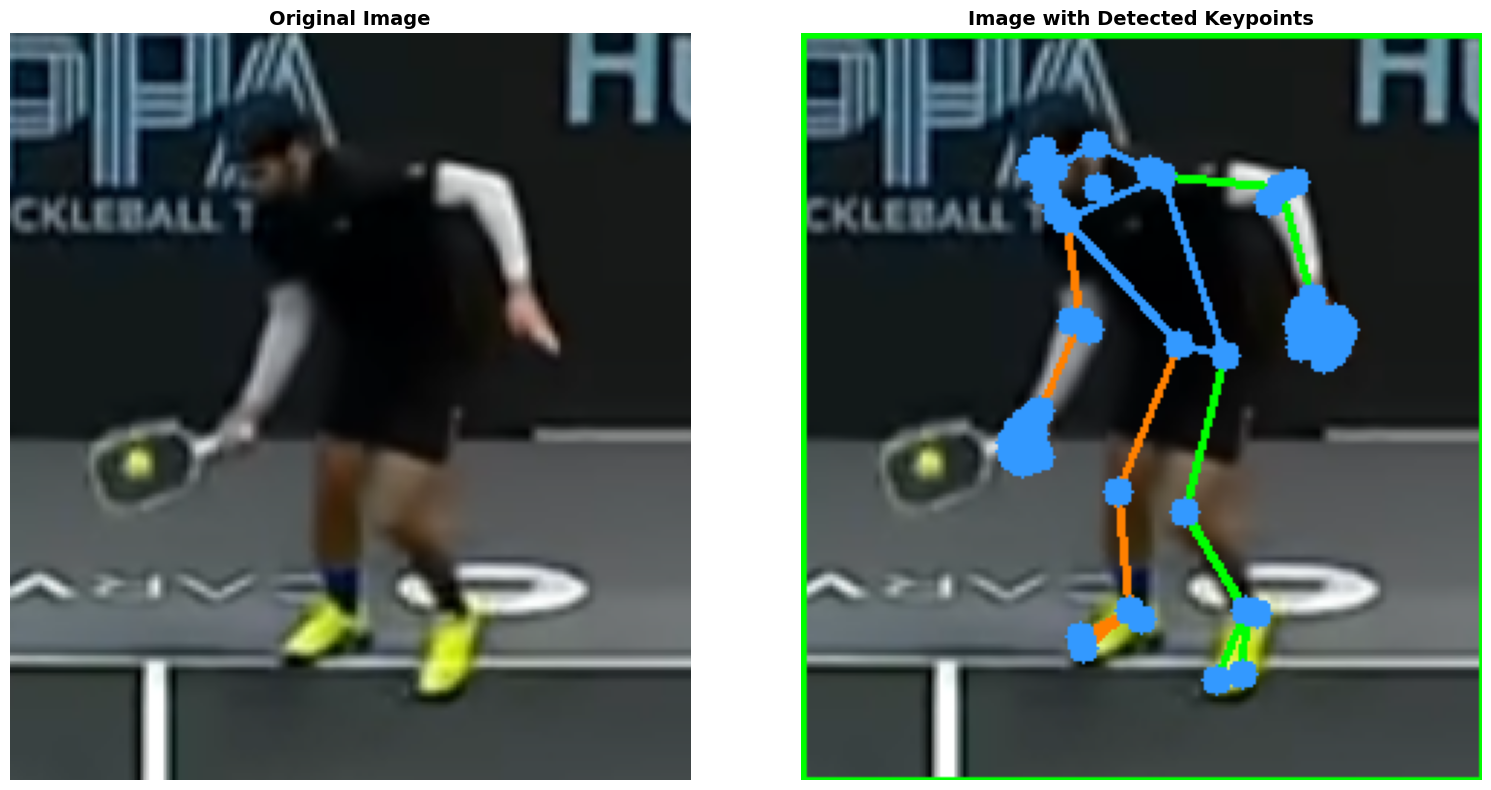

✅ Displayed image: drop-shovel-7.png
   Detected 70 keypoints
   Bounding box: [0.0, 0.0, 235.0, 258.0]


In [4]:

# Visualization imports
import cv2
import numpy as np

# Setup visualization tools from SAM 3D Body
sam3d_path = str(project_root / 'models' / 'sam-3d-body')
if sam3d_path not in sys.path:
    sys.path.insert(0, sam3d_path)

from sam_3d_body.visualization.skeleton_visualizer import SkeletonVisualizer
from sam_3d_body.metadata.mhr70 import pose_info as mhr70_pose_info

# Initialize visualizer
visualizer = SkeletonVisualizer(line_width=2, radius=5)
visualizer.set_pose_meta(mhr70_pose_info)

# Display the original image
if 'pose_data' in locals() and 'image_path' in locals():
    img = cv2.imread(str(image_path))
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Draw keypoints on image
        keypoints_2d = pose_data['pred_keypoints_2d']
        # Add visibility column (all visible for now)
        keypoints_2d_with_vis = np.concatenate(
            [keypoints_2d, np.ones((keypoints_2d.shape[0], 1))], axis=-1
        )
        img_with_keypoints = visualizer.draw_skeleton(img_rgb.copy(), keypoints_2d_with_vis)
        
        # Draw bounding box
        bbox = pose_data['bbox']
        img_with_keypoints = cv2.rectangle(
            img_with_keypoints,
            (int(bbox[0]), int(bbox[1])),
            (int(bbox[2]), int(bbox[3])),
            (0, 255, 0),
            2,
        )
        
        # Display side by side
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        axes[0].imshow(img_rgb)
        axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
        axes[0].axis('off')
        
        axes[1].imshow(img_with_keypoints)
        axes[1].set_title('Image with Detected Keypoints', fontsize=14, fontweight='bold')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"✅ Displayed image: {image_path.name}")
        print(f"   Detected {len(keypoints_2d)} keypoints")
        print(f"   Bounding box: [{bbox[0]:.1f}, {bbox[1]:.1f}, {bbox[2]:.1f}, {bbox[3]:.1f}]")
    else:
        print("⚠️  Could not load image for visualization")
else:
    print("⚠️  Run Step 3 first to process an image")

## Step 4: Extract Keypoints

**Key API: `extract_keypoints()`**

This function extracts specific keypoints by name from the pose data.

**Available keypoints:**
- Upper body: `left_shoulder`, `right_shoulder`, `left_elbow`, `right_elbow`, `left_wrist`, `right_wrist`, `neck`
- Lower body: `left_hip`, `right_hip`, `left_knee`, `right_knee`, `left_ankle`, `right_ankle`
- Head: `nose`, `left_eye`, `right_eye`, `left_ear`, `right_ear`

**Key API: `calculate_body_center()`**

Calculates the center of the body using hip keypoints.

In [5]:
# Extract keypoints by name
keypoints = extract_keypoints(pose_data)

print("✅ Extracted keypoints:")
print(f"   Available keypoints: {len(keypoints)}")
print()

# Show some example keypoints
example_keypoints = ['left_shoulder', 'right_shoulder', 'left_hip', 'right_hip', 'left_wrist', 'right_wrist']
for name in example_keypoints:
    if name in keypoints and keypoints[name] is not None:
        coords = keypoints[name]
        print(f"   {name:20s}: [{coords[0]:7.3f}, {coords[1]:7.3f}, {coords[2]:7.3f}]")
    else:
        print(f"   {name:20s}: Not available")

# Calculate body center
body_center = calculate_body_center(pose_data)
print()
print(f"✅ Body center: [{body_center[0]:7.3f}, {body_center[1]:7.3f}, {body_center[2]:7.3f}]")

✅ Extracted keypoints:
   Available keypoints: 18

   left_shoulder       : [ -0.122,  -1.285,  -0.375]
   right_shoulder      : [ -0.358,  -1.231,  -0.123]
   left_hip            : [  0.057,  -0.885,  -0.052]
   right_hip           : [ -0.062,  -0.919,   0.060]
   left_wrist          : [  0.225,  -1.004,  -0.393]
   right_wrist         : [ -0.435,  -0.739,  -0.019]

✅ Body center: [ -0.003,  -0.902,   0.004]


## Step 5: Score Preparation Position

**Key API: `score_preparation_position()`**

Scores the preparation position based on:
- **Shoulder angle**: Angle between shoulders and hips (should be open)
- **Weight distribution**: Balance between left and right hips
- **Knee bend**: Angle of knee joints (should be slightly bent)

**Returns:**
- Individual metric scores (0-100)
- Weighted overall preparation score (0-100)

In [6]:
# Score preparation position
prep_score = score_preparation_position(pose_data)

print("✅ Preparation Position Score:")
print(f"   Overall Score: {prep_score['preparation_score']:.2f}/100")
print()
print("   Individual Metrics:")
print(f"   - Shoulder Angle Score: {prep_score['scores']['shoulder_angle']:.2f}/100")
print(f"     (Right: {prep_score['shoulder_angle_right']:.1f}°, Left: {prep_score['shoulder_angle_left']:.1f}°)")
print(f"   - Weight Distribution Score: {prep_score['scores']['weight_distribution']:.2f}/100")
print(f"     (Hip height difference: {prep_score['hip_height_diff']*100:.2f} cm)")
print(f"   - Knee Bend Score: {prep_score['scores']['knee_bend']:.2f}/100")
print(f"     (Left knee: {prep_score['knee_angles']['left']:.1f}°, Right knee: {prep_score['knee_angles']['right']:.1f}°)")

✅ Preparation Position Score:
   Overall Score: 17.49/100

   Individual Metrics:
   - Shoulder Angle Score: 22.01/100
     (Right: 33.8°, Left: 65.4°)
   - Weight Distribution Score: 10.00/100
     (Hip height difference: 11.16 cm)
   - Knee Bend Score: 28.43/100
     (Left knee: 114.4°, Right knee: 140.3°)


### 4.1 Visualization: Preparation Position Metrics

Visualize the preparation position scores and key metrics.

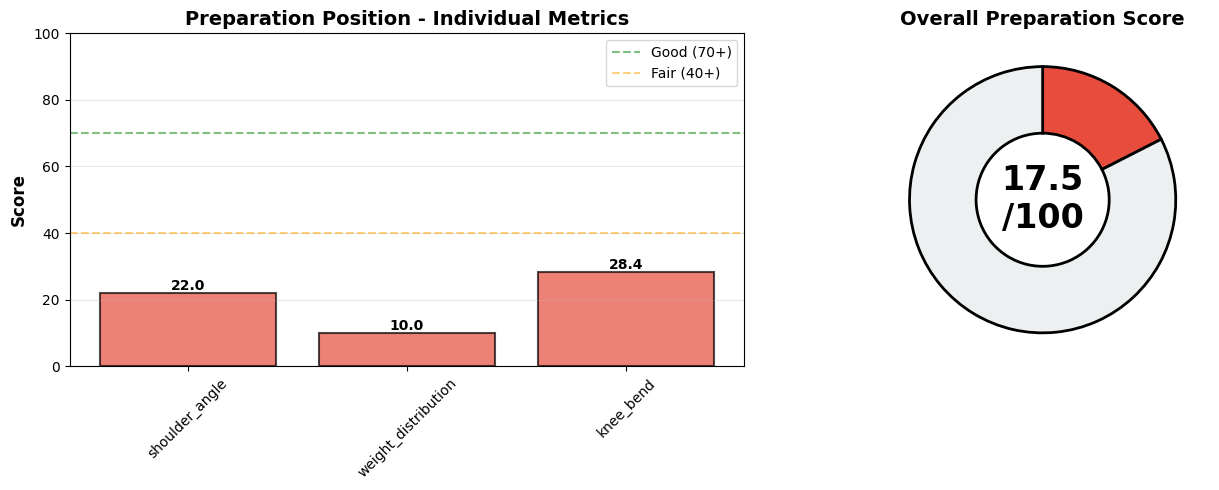

📊 Key Metrics:
   Shoulder Angles: Left=65.4°, Right=33.8°
   Hip Height Difference: 11.16 cm
   Knee Angles: Left=114.4°, Right=140.3°


In [7]:

    
# Visualize preparation position scores
if 'prep_score' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart of individual scores
    scores = prep_score['scores']
    score_names = list(scores.keys())
    score_values = list(scores.values())
    
    colors = ['#2ecc71' if v >= 70 else '#f39c12' if v >= 40 else '#e74c3c' for v in score_values]
    bars = axes[0].bar(score_names, score_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0].axhline(y=70, color='green', linestyle='--', alpha=0.5, label='Good (70+)')
    axes[0].axhline(y=40, color='orange', linestyle='--', alpha=0.5, label='Fair (40+)')
    axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
    axes[0].set_title('Preparation Position - Individual Metrics', fontsize=14, fontweight='bold')
    axes[0].set_ylim(0, 100)
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, val in zip(bars, score_values):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.1f}',
                    ha='center', va='bottom', fontweight='bold')
    
    # Overall score gauge
    overall_score = prep_score['preparation_score']
    axes[1].pie([overall_score, 100 - overall_score], 
                startangle=90, counterclock=False,
                colors=['#2ecc71' if overall_score >= 70 else '#f39c12' if overall_score >= 40 else '#e74c3c', '#ecf0f1'],
                wedgeprops=dict(width=0.5, edgecolor='black', linewidth=2))
    axes[1].text(0, 0, f'{overall_score:.1f}\n/100', 
                ha='center', va='center', fontsize=24, fontweight='bold')
    axes[1].set_title('Overall Preparation Score', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print key metrics
    print("📊 Key Metrics:")
    print(f"   Shoulder Angles: Left={prep_score['shoulder_angle_left']:.1f}°, Right={prep_score['shoulder_angle_right']:.1f}°")
    print(f"   Hip Height Difference: {prep_score['hip_height_diff']*100:.2f} cm")
    print(f"   Knee Angles: Left={prep_score['knee_angles']['left']:.1f}°, Right={prep_score['knee_angles']['right']:.1f}°")
else:
    print("⚠️  Run Step 5 first to score preparation position")

## Step 6: Score Contact Position

**Key API: `score_contact_position()`**

Scores the contact position (point of contact between paddle and ball) based on:
- **Paddle position**: Wrist position relative to body (should be in front of body)
- **Contact height**: Height of paddle at contact point
- **Body alignment**: Shoulder and hip alignment in frontal plane
- **Torso angle**: Forward lean angle (optional metric)

**Returns:**
- Individual metric scores (0-100)
- Weighted overall contact score (0-100)

In [8]:
# Score contact position
contact_score = score_contact_position(pose_data)

print("✅ Contact Position Score:")
print(f"   Overall Score: {contact_score['contact_score']:.2f}/100")
print()
print("   Individual Metrics:")
print(f"   - Paddle Position Score: {contact_score['scores']['paddle_position']:.2f}/100")
print(f"   - Body Alignment Score: {contact_score['scores']['body_alignment']:.2f}/100")
print(f"   - Contact Height Score: {contact_score['scores']['contact_height']:.2f}/100")
print(f"     (Paddle height: {contact_score['paddle_height']:.3f}m)")
if contact_score.get('torso_angle') is not None:
    print(f"   - Torso Angle Score: {contact_score['scores'].get('torso_angle', 0.0):.2f}/100")
    print(f"     (Torso angle: {contact_score['torso_angle']:.1f}°)")

✅ Contact Position Score:
   Overall Score: 8.75/100

   Individual Metrics:
   - Paddle Position Score: 25.00/100
   - Body Alignment Score: 0.00/100
   - Contact Height Score: 0.00/100
     (Paddle height: -0.019m)
   - Torso Angle Score: 0.00/100
     (Torso angle: -30.6°)


### 6.1 Visualization: Contact Position Metrics

Visualize the contact position scores and key metrics.

**Note:** Run Step 6 first to create `contact_score`.

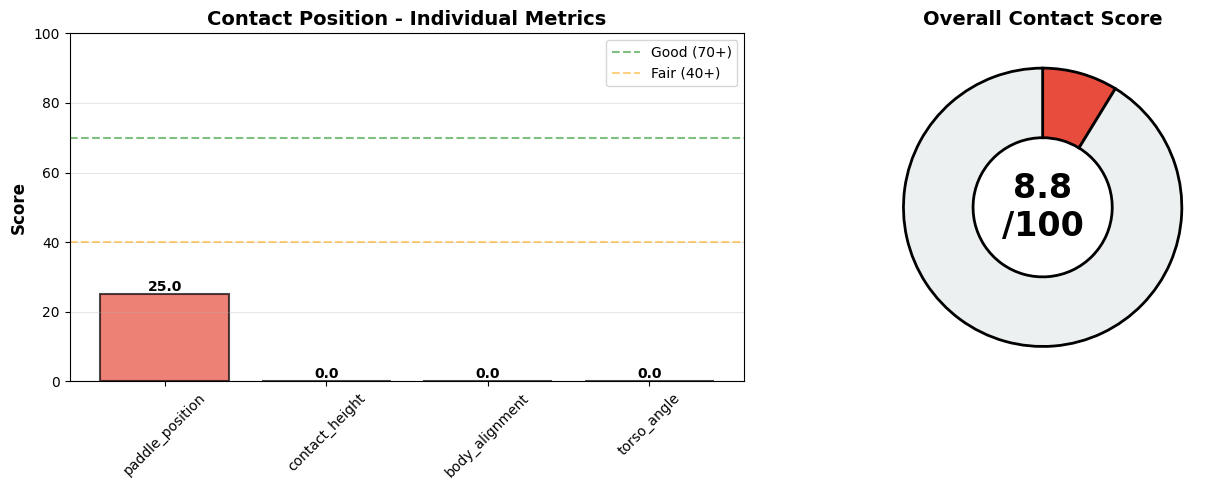

📊 Key Metrics:
   Paddle Position (relative to body): X=-0.432m, Y=0.163m, Z=-0.023m
   Paddle Height: -0.019m
   Body Alignment: 0.000
   Torso Angle: -30.6°


In [9]:
# Visualize contact position scores
# Check if contact_score exists (use try-except for Jupyter compatibility)
try:
    # Try to access contact_score - works if created in previous cell
    _ = contact_score
    contact_score_available = True
except NameError:
    contact_score_available = False

if contact_score_available:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart of individual scores
    scores = contact_score['scores']
    score_names = list(scores.keys())
    score_values = list(scores.values())
    
    colors = ['#2ecc71' if v >= 70 else '#f39c12' if v >= 40 else '#e74c3c' for v in score_values]
    bars = axes[0].bar(score_names, score_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0].axhline(y=70, color='green', linestyle='--', alpha=0.5, label='Good (70+)')
    axes[0].axhline(y=40, color='orange', linestyle='--', alpha=0.5, label='Fair (40+)')
    axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
    axes[0].set_title('Contact Position - Individual Metrics', fontsize=14, fontweight='bold')
    axes[0].set_ylim(0, 100)
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, val in zip(bars, score_values):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.1f}',
                    ha='center', va='bottom', fontweight='bold')
    
    # Overall score gauge
    overall_score = contact_score['contact_score']
    axes[1].pie([overall_score, 100 - overall_score], 
                startangle=90, counterclock=False,
                colors=['#2ecc71' if overall_score >= 70 else '#f39c12' if overall_score >= 40 else '#e74c3c', '#ecf0f1'],
                wedgeprops=dict(width=0.5, edgecolor='black', linewidth=2))
    axes[1].text(0, 0, f'{overall_score:.1f}\n/100', 
                ha='center', va='center', fontsize=24, fontweight='bold')
    axes[1].set_title('Overall Contact Score', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print key metrics
    print("📊 Key Metrics:")
    if contact_score.get('paddle_position') is not None:
        paddle_pos = contact_score['paddle_position']
        print(f"   Paddle Position (relative to body): X={paddle_pos[0]:.3f}m, Y={paddle_pos[1]:.3f}m, Z={paddle_pos[2]:.3f}m")
    print(f"   Paddle Height: {contact_score['paddle_height']:.3f}m")
    print(f"   Body Alignment: {contact_score['body_alignment']:.3f}")
    if contact_score.get('torso_angle') is not None:
        print(f"   Torso Angle: {contact_score['torso_angle']:.1f}°")
else:
    print("⚠️  Run Step 6 first to score contact position")

### Visualization: Joint Angles

Visualize key joint angles calculated from the 3D keypoints.

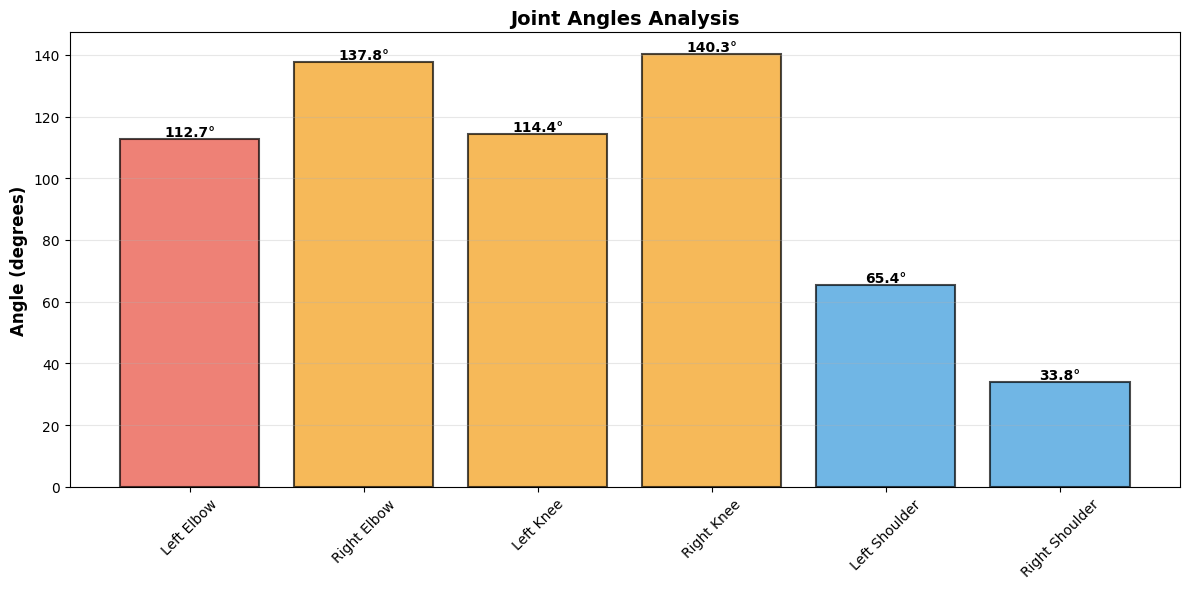

✅ Displayed joint angles

📐 Angle Reference:
   Elbow: 140-180° = straight/extended, <140° = bent
   Knee: 160-180° = straight, 90-160° = bent, <90° = very bent


In [10]:
# Visualize joint angles
if 'pose_data' in locals():
    keypoints = extract_keypoints(pose_data)
    angles_data = {}
    
    # Calculate various angles
    angle_pairs = [
        ('Left Elbow', ['left_shoulder', 'left_elbow', 'left_wrist']),
        ('Right Elbow', ['right_shoulder', 'right_elbow', 'right_wrist']),
        ('Left Knee', ['left_hip', 'left_knee', 'left_ankle']),
        ('Right Knee', ['right_hip', 'right_knee', 'right_ankle']),
        ('Left Shoulder', ['left_elbow', 'left_shoulder', 'left_hip']),
        ('Right Shoulder', ['right_elbow', 'right_shoulder', 'right_hip']),
    ]
    
    for angle_name, kp_names in angle_pairs:
        if all(k in keypoints and keypoints[k] is not None for k in kp_names):
            angle = calculate_3d_angle(
                keypoints[kp_names[0]],
                keypoints[kp_names[1]],
                keypoints[kp_names[2]]
            )
            angles_data[angle_name] = angle
    
    if angles_data:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        angle_names = list(angles_data.keys())
        angle_values = list(angles_data.values())
        
        # Color code: green for good range, yellow for moderate, red for extreme
        colors = []
        for name, val in angles_data.items():
            if 'Elbow' in name:
                # Elbow: 140-180° is good (straight)
                if 140 <= val <= 180:
                    colors.append('#2ecc71')
                elif 120 <= val < 140 or 180 < val <= 200:
                    colors.append('#f39c12')
                else:
                    colors.append('#e74c3c')
            elif 'Knee' in name:
                # Knee: 160-180° is good (straight), 90-160° is bent
                if 160 <= val <= 180:
                    colors.append('#2ecc71')
                elif 90 <= val < 160:
                    colors.append('#f39c12')
                else:
                    colors.append('#e74c3c')
            else:
                colors.append('#3498db')
        
        bars = ax.bar(angle_names, angle_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
        ax.set_ylabel('Angle (degrees)', fontsize=12, fontweight='bold')
        ax.set_title('Joint Angles Analysis', fontsize=14, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels
        for bar, val in zip(bars, angle_values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.1f}°',
                   ha='center', va='bottom', fontweight='bold', fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        print("✅ Displayed joint angles")
        print("\n📐 Angle Reference:")
        print("   Elbow: 140-180° = straight/extended, <140° = bent")
        print("   Knee: 160-180° = straight, 90-160° = bent, <90° = very bent")
    else:
        print("⚠️  Could not calculate angles - missing keypoints")
else:
    print("⚠️  Run Step 3 first to process an image")

## Step 7: Score Finish Position

**Key API: `score_finish_position()`**

Scores the finish position (end of swing) based on:
- **Finish position**: Wrist position and height at finish
- **Follow-through angle**: Shoulder-elbow-wrist angle (full arm extension)
- **Body rotation**: Hip and shoulder rotation alignment

**Returns:**
- Individual metric scores (0-100)
- Weighted overall finish score (0-100)

In [11]:
# Score finish position
finish_score = score_finish_position(pose_data)

print("✅ Finish Position Score:")
print(f"   Overall Score: {finish_score['finish_score']:.2f}/100")
print()
print("   Individual Metrics:")
print(f"   - Finish Position Score: {finish_score['scores']['finish_position']:.2f}/100")
print(f"     (Finish position: {finish_score['finish_position']})")
print(f"   - Follow-through Angle Score: {finish_score['scores']['follow_through']:.2f}/100")
print(f"     (Follow-through angle: {finish_score['follow_through_angle']:.1f}°)")
print(f"   - Body Rotation Score: {finish_score['scores']['body_rotation']:.2f}/100")
print(f"     (Body rotation metric: {finish_score['body_rotation']:.3f})")

✅ Finish Position Score:
   Overall Score: 18.75/100

   Individual Metrics:
   - Finish Position Score: 0.00/100
     (Finish position: [-0.4347847  -0.7390888  -0.01915504])
   - Follow-through Angle Score: 0.00/100
     (Follow-through angle: 137.8°)
   - Body Rotation Score: 75.00/100
     (Body rotation metric: 0.750)


### 7.1 Visualization: Finish Position Metrics

Visualize the finish position scores and key metrics.

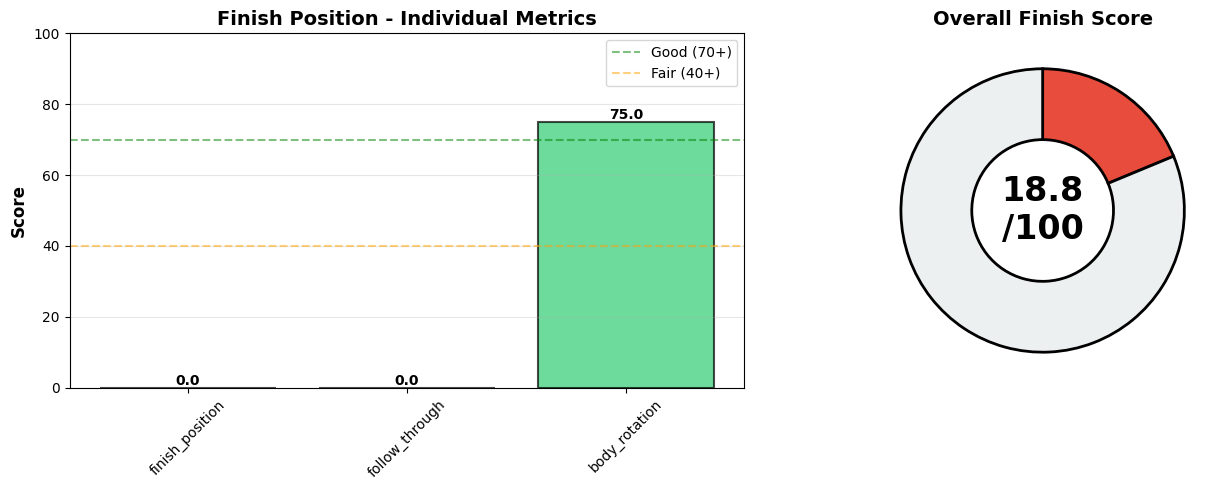

📊 Key Metrics:
   Finish Position: X=-0.435m, Y=-0.739m, Z=-0.019m
   Follow-through Angle: 137.8°
   Body Rotation: 0.750


In [12]:
# Visualize finish position scores
if 'finish_score' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart of individual scores
    scores = finish_score['scores']
    score_names = list(scores.keys())
    score_values = list(scores.values())
    
    colors = ['#2ecc71' if v >= 70 else '#f39c12' if v >= 40 else '#e74c3c' for v in score_values]
    bars = axes[0].bar(score_names, score_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0].axhline(y=70, color='green', linestyle='--', alpha=0.5, label='Good (70+)')
    axes[0].axhline(y=40, color='orange', linestyle='--', alpha=0.5, label='Fair (40+)')
    axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
    axes[0].set_title('Finish Position - Individual Metrics', fontsize=14, fontweight='bold')
    axes[0].set_ylim(0, 100)
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, val in zip(bars, score_values):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.1f}',
                    ha='center', va='bottom', fontweight='bold')
    
    # Overall score gauge
    overall_score = finish_score['finish_score']
    axes[1].pie([overall_score, 100 - overall_score], 
                startangle=90, counterclock=False,
                colors=['#2ecc71' if overall_score >= 70 else '#f39c12' if overall_score >= 40 else '#e74c3c', '#ecf0f1'],
                wedgeprops=dict(width=0.5, edgecolor='black', linewidth=2))
    axes[1].text(0, 0, f'{overall_score:.1f}\n/100', 
                ha='center', va='center', fontsize=24, fontweight='bold')
    axes[1].set_title('Overall Finish Score', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print key metrics
    print("📊 Key Metrics:")
    if finish_score.get('finish_position') is not None:
        finish_pos = finish_score['finish_position']
        print(f"   Finish Position: X={finish_pos[0]:.3f}m, Y={finish_pos[1]:.3f}m, Z={finish_pos[2]:.3f}m")
    if finish_score.get('follow_through_angle') is not None:
        print(f"   Follow-through Angle: {finish_score['follow_through_angle']:.1f}°")
    print(f"   Body Rotation: {finish_score['body_rotation']:.3f}")
else:
    print("⚠️  Run Step 7 first to score finish position")

### 7.2 Visualization: Comprehensive Metrics Dashboard

A comprehensive view of all metrics and scores in one place.

In [18]:

    
# Comprehensive metrics dashboard
if all(k in locals() for k in ['prep_score', 'contact_score', 'finish_score']):
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Overall scores comparison (top left, spans 2 columns)
    ax1 = fig.add_subplot(gs[0, :2])
    positions = ['Preparation', 'Contact', 'Finish']
    scores = [prep_score['preparation_score'], 
             contact_score['contact_score'],
             finish_score['finish_score']]
    cumulative = sum(scores) / len(scores)
    
    colors = ['#2ecc71' if s >= 70 else '#f39c12' if s >= 40 else '#e74c3c' for s in scores]
    bars = ax1.bar(positions, scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax1.axhline(y=70, color='green', linestyle='--', alpha=0.5)
    ax1.axhline(y=40, color='orange', linestyle='--', alpha=0.5)
    ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax1.set_title('Overall Scores by Position', fontsize=12, fontweight='bold')
    ax1.set_ylim(0, 100)
    ax1.grid(axis='y', alpha=0.3)
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.1f}', ha='center', va='bottom', fontweight='bold')
    ax1.text(0.5, 0.95, f'Cumulative: {cumulative:.1f}/100',
            transform=ax1.transAxes, ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 2. Preparation metrics breakdown
    ax2 = fig.add_subplot(gs[0, 2])
    prep_metrics = list(prep_score['scores'].keys())
    prep_values = list(prep_score['scores'].values())
    ax2.barh(prep_metrics, prep_values, color='#3498db', alpha=0.7)
    ax2.set_xlim(0, 100)
    ax2.set_title('Preparation\nMetrics', fontsize=10, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # 3. Contact metrics breakdown
    ax3 = fig.add_subplot(gs[1, 0])
    contact_metrics = list(contact_score['scores'].keys())
    contact_values = list(contact_score['scores'].values())
    ax3.barh(contact_metrics, contact_values, color='#e74c3c', alpha=0.7)
    ax3.set_xlim(0, 100)
    ax3.set_title('Contact\nMetrics', fontsize=10, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    
    # 4. Finish metrics breakdown
    ax4 = fig.add_subplot(gs[1, 1])
    finish_metrics = list(finish_score['scores'].keys())
    finish_values = list(finish_score['scores'].values())
    ax4.barh(finish_metrics, finish_values, color='#9b59b6', alpha=0.7)
    ax4.set_xlim(0, 100)
    ax4.set_title('Finish\nMetrics', fontsize=10, fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)
    
    # 5. Key angles visualization
    ax5 = fig.add_subplot(gs[1, 2])
    if 'pose_data' in locals():
        keypoints = extract_keypoints(pose_data)
        angles_to_show = {}
        angle_configs = [
            ('Left Elbow', ['left_shoulder', 'left_elbow', 'left_wrist']),
            ('Right Elbow', ['right_shoulder', 'right_elbow', 'right_wrist']),
            ('Left Knee', ['left_hip', 'left_knee', 'left_ankle']),
        ]
        for name, kp_names in angle_configs:
            if all(k in keypoints and keypoints[k] is not None for k in kp_names):
                angles_to_show[name] = calculate_3d_angle(
                    keypoints[kp_names[0]], keypoints[kp_names[1]], keypoints[kp_names[2]]
                )
        if angles_to_show:
            ax5.barh(list(angles_to_show.keys()), list(angles_to_show.values()), 
                    color='#f39c12', alpha=0.7)
            ax5.set_xlabel('Angle (degrees)', fontsize=9)
            ax5.set_title('Key Joint\nAngles', fontsize=10, fontweight='bold')
            ax5.grid(axis='x', alpha=0.3)
    
    # 6. Score distribution (bottom, spans all columns)
    ax6 = fig.add_subplot(gs[2, :])
    all_scores = []
    all_labels = []
    for pos, score_dict in [('Prep', prep_score['scores']), 
                           ('Contact', contact_score['scores']),
                           ('Finish', finish_score['scores'])]:
        for metric, val in score_dict.items():
            all_scores.append(val)
            all_labels.append(f'{pos}\n{metric}')
    
    ax6.hist(all_scores, bins=20, color='#3498db', alpha=0.7, edgecolor='black')
    ax6.axvline(x=70, color='green', linestyle='--', alpha=0.7, label='Good (70+)')
    ax6.axvline(x=40, color='orange', linestyle='--', alpha=0.7, label='Fair (40+)')
    ax6.set_xlabel('Score', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax6.set_title('Score Distribution Across All Metrics', fontsize=12, fontweight='bold')
    ax6.legend()
    ax6.grid(alpha=0.3)
    
    plt.suptitle('Pickleball Pose Analysis - Comprehensive Dashboard', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    
    print("✅ Displayed comprehensive metrics dashboard")
else:
    print("⚠️  Run Steps 5, 6, and 7 first to generate all scores")

⚠️  Run Steps 5, 6, and 7 first to generate all scores


## Step 8: Process Three Positions Together

**Key API: `process_three_positions()`**

This function processes three images (preparation, contact, finish) in one call and returns structured data for all three positions.

**Parameters:**
- `estimator`: SAM3DBodyEstimator instance
- `preparation_path`: Path to preparation image
- `contact_path`: Path to contact image
- `finish_path`: Path to finish image

**Returns:**
- Dictionary with keys: `'preparation'`, `'contact'`, `'finish'`
- Each contains the same structure as `process_single_image()` output

In [19]:
# Example: Process three positions
# Update these paths to your actual pickleball pose images
preparation_path = data_dir / 'drop-shovel-1.png'  # Update as needed
contact_path = data_dir / 'drop-shovel-7.png'      # Update as needed
finish_path = data_dir / 'drop-shovel-8.png'        # Update as needed

# Check if images exist
images_exist = all(p.exists() for p in [preparation_path, contact_path, finish_path])

if images_exist:
    print("Processing three positions...")
    print(f"   Preparation: {preparation_path.name}")
    print(f"   Contact: {contact_path.name}")
    print(f"   Finish: {finish_path.name}")
    print()
    
    # Process all three positions
    results = process_three_positions(
        estimator=estimator,
        preparation_path=str(preparation_path),
        contact_path=str(contact_path),
        finish_path=str(finish_path),
    )
    
    print("✅ All three positions processed!")
    print()
    
    # Score each position
    prep_score = score_preparation_position(results['preparation'])
    contact_score = score_contact_position(results['contact'])
    finish_score = score_finish_position(results['finish'])
    
    # Display summary
    print("=" * 60)
    print("SCORING SUMMARY")
    print("=" * 60)
    print(f"Preparation Score: {prep_score['preparation_score']:.2f}/100")
    print(f"Contact Score:     {contact_score['contact_score']:.2f}/100")
    print(f"Finish Score:       {finish_score['finish_score']:.2f}/100")
    print()
    
    # Calculate cumulative score (average of all three)
    cumulative_score = (
        prep_score['preparation_score'] +
        contact_score['contact_score'] +
        finish_score['finish_score']
    ) / 3.0
    print(f"Cumulative Score:   {cumulative_score:.2f}/100")
    print("=" * 60)
else:
    print("⚠️  Some images not found. Please update the image paths above.")
    print("   You need three images: preparation, contact, and finish positions")

Processing three positions...
   Preparation: drop-shovel-1.png
   Contact: drop-shovel-7.png
   Finish: drop-shovel-8.png

Processing preparation position...
Processing contact position...
Processing finish position...
✅ All three positions processed!

SCORING SUMMARY
Preparation Score: 32.28/100
Contact Score:     8.75/100
Finish Score:       18.75/100

Cumulative Score:   19.93/100


### 8.1 Visualization: Three Positions Comparison

Display all three images side-by-side and compare scores across positions.
    

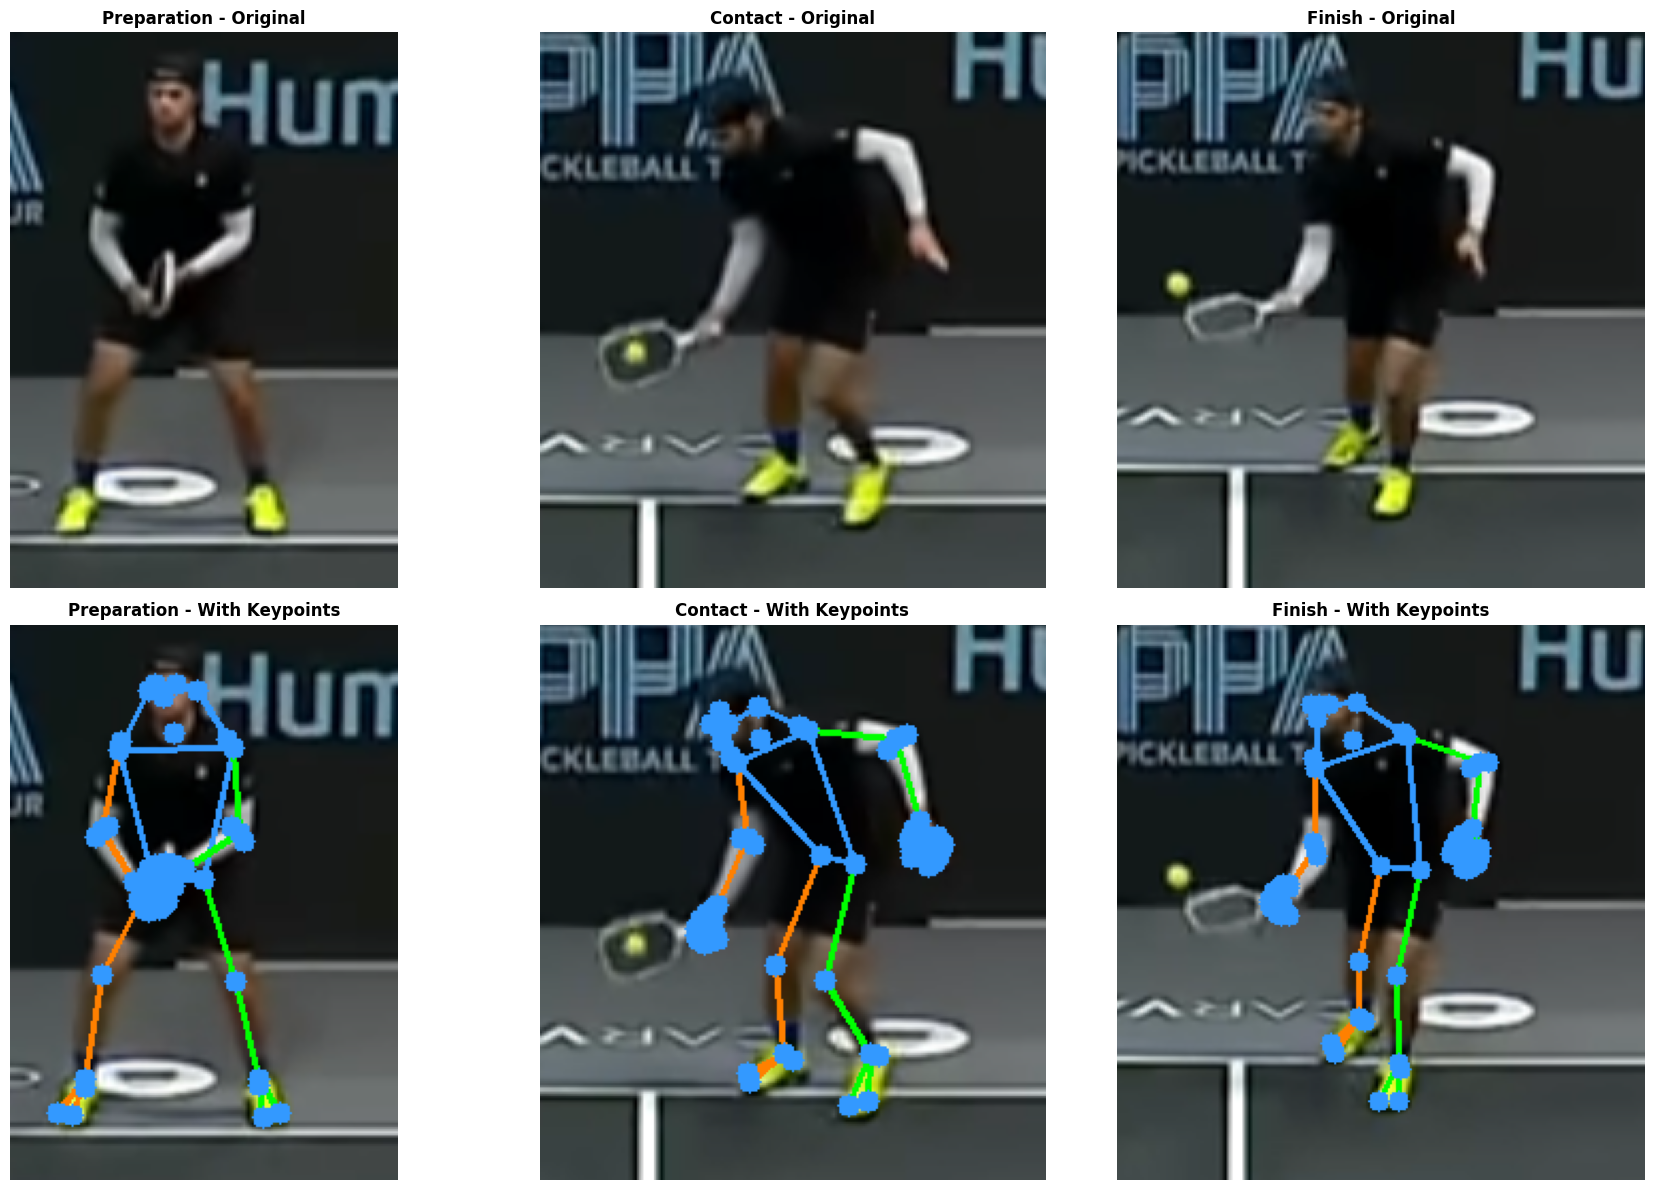

In [20]:

# Visualize three positions comparison
if 'results' in locals() and all(k in results for k in ['preparation', 'contact', 'finish']):
    # Load and display images
    prep_img = cv2.imread(str(preparation_path))
    contact_img = cv2.imread(str(contact_path))
    finish_img = cv2.imread(str(finish_path))
    
    if all(img is not None for img in [prep_img, contact_img, finish_img]):
        prep_img_rgb = cv2.cvtColor(prep_img, cv2.COLOR_BGR2RGB)
        contact_img_rgb = cv2.cvtColor(contact_img, cv2.COLOR_BGR2RGB)
        finish_img_rgb = cv2.cvtColor(finish_img, cv2.COLOR_BGR2RGB)
        
        # Draw keypoints on each image
        images_with_keypoints = []
        for img_rgb, pose_data_pos in [(prep_img_rgb, results['preparation']), 
                                       (contact_img_rgb, results['contact']),
                                       (finish_img_rgb, results['finish'])]:
            keypoints_2d = pose_data_pos['pred_keypoints_2d']
            keypoints_2d_with_vis = np.concatenate(
                [keypoints_2d, np.ones((keypoints_2d.shape[0], 1))], axis=-1
            )
            img_kp = visualizer.draw_skeleton(img_rgb.copy(), keypoints_2d_with_vis)
            images_with_keypoints.append(img_kp)
        
        # Display images
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        positions = ['Preparation', 'Contact', 'Finish']
        images = [prep_img_rgb, contact_img_rgb, finish_img_rgb]
        images_kp = images_with_keypoints
        
        for i, (pos, img, img_kp) in enumerate(zip(positions, images, images_kp)):
            axes[0, i].imshow(img)
            axes[0, i].set_title(f'{pos} - Original', fontsize=12, fontweight='bold')
            axes[0, i].axis('off')
            
            axes[1, i].imshow(img_kp)
            axes[1, i].set_title(f'{pos} - With Keypoints', fontsize=12, fontweight='bold')
            axes[1, i].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Score comparison chart
        if all(k in locals() for k in ['prep_score', 'contact_score', 'finish_score']):
            fig, ax = plt.subplots(figsize=(10, 6))
            
            positions = ['Preparation', 'Contact', 'Finish']
            scores = [prep_score['preparation_score'], 
                     contact_score['contact_score'],
                     finish_score['finish_score']]
            
            colors = ['#2ecc71' if s >= 70 else '#f39c12' if s >= 40 else '#e74c3c' for s in scores]
            bars = ax.bar(positions, scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
            
            ax.axhline(y=70, color='green', linestyle='--', alpha=0.5, label='Good (70+)')
            ax.axhline(y=40, color='orange', linestyle='--', alpha=0.5, label='Fair (40+)')
            ax.set_ylabel('Score', fontsize=12, fontweight='bold')
            ax.set_title('Score Comparison Across All Three Positions', fontsize=14, fontweight='bold')
            ax.set_ylim(0, 100)
            ax.grid(axis='y', alpha=0.3)
            ax.legend()
            
            # Add value labels
            for bar, score in zip(bars, scores):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{score:.1f}',
                       ha='center', va='bottom', fontsize=14, fontweight='bold')
            
            # Add cumulative score
            cumulative = sum(scores) / len(scores)
            ax.text(0.5, 0.95, f'Cumulative Score: {cumulative:.1f}/100',
                   transform=ax.transAxes, ha='center', fontsize=12, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            plt.tight_layout()
            plt.show()
            
            print("✅ Displayed three positions comparison")
    else:
        print("⚠️  Could not load all images for visualization")
else:
    print("⚠️  Run Step 8 first to process three positions")

## Step 9: Calculate 3D Angles

**Key API: `calculate_3d_angle()`**

Utility function to calculate the angle between three 3D points (useful for joint angles).

**Parameters:**
- `point1`, `point2`, `point3`: Three 3D points (numpy arrays)
- `point2` is the vertex of the angle

**Returns:**
- Angle in degrees (0-180°)

In [16]:
# Example: Calculate elbow angle
if 'pose_data' in locals():
    keypoints = extract_keypoints(pose_data)
    
    # Calculate left elbow angle (shoulder-elbow-wrist)
    if all(k in keypoints and keypoints[k] is not None 
           for k in ['left_shoulder', 'left_elbow', 'left_wrist']):
        elbow_angle = calculate_3d_angle(
            keypoints['left_shoulder'],
            keypoints['left_elbow'],
            keypoints['left_wrist']
        )
        print(f"✅ Left elbow angle: {elbow_angle:.1f}°")
    
    # Calculate right elbow angle
    if all(k in keypoints and keypoints[k] is not None 
           for k in ['right_shoulder', 'right_elbow', 'right_wrist']):
        elbow_angle = calculate_3d_angle(
            keypoints['right_shoulder'],
            keypoints['right_elbow'],
            keypoints['right_wrist']
        )
        print(f"✅ Right elbow angle: {elbow_angle:.1f}°")
    
    # Calculate knee angle (hip-knee-ankle)
    if all(k in keypoints and keypoints[k] is not None 
           for k in ['left_hip', 'left_knee', 'left_ankle']):
        knee_angle = calculate_3d_angle(
            keypoints['left_hip'],
            keypoints['left_knee'],
            keypoints['left_ankle']
        )
        print(f"✅ Left knee angle: {knee_angle:.1f}°")

✅ Left elbow angle: 112.7°
✅ Right elbow angle: 137.8°
✅ Left knee angle: 114.4°


## Step 10: Data Structures

**Key Data Classes:**

- **`PoseData`**: Structured container for pose data
  - `keypoints_3d`: 3D keypoints array
  - `keypoints_2d`: 2D keypoints array
  - `vertices`: Mesh vertices
  - `pose_params`: Pose parameters
  - `metadata`: Image metadata

- **`PositionScore`**: Container for position scores
  - `overall_score`: Overall score (0-100)
  - `metric_scores`: Dictionary of individual metric scores
  - `raw_metrics`: Raw metric values

- **`PICKLEBALL_KEYPOINTS`**: Dictionary mapping keypoint names to indices
- **`KEYPOINT_NAMES_TO_INDICES`**: Reverse mapping for easy lookup

In [17]:
# Display available keypoints
print("Available Pickleball Keypoints:")
print("=" * 40)
for name, idx in sorted(PICKLEBALL_KEYPOINTS.items(), key=lambda x: x[1]):
    print(f"  {name:20s} -> index {idx:2d}")

print()
print(f"Total keypoints: {len(PICKLEBALL_KEYPOINTS)}")

Available Pickleball Keypoints:
  nose                 -> index  0
  left_eye             -> index  1
  right_eye            -> index  2
  left_ear             -> index  3
  right_ear            -> index  4
  left_shoulder        -> index  5
  right_shoulder       -> index  6
  left_elbow           -> index  7
  right_elbow          -> index  8
  left_hip             -> index  9
  right_hip            -> index 10
  left_knee            -> index 11
  right_knee           -> index 12
  left_ankle           -> index 13
  right_ankle          -> index 14
  right_wrist          -> index 41
  left_wrist           -> index 62
  neck                 -> index 69

Total keypoints: 18


## Summary

This notebook verified the Phase 1 implementation:

✅ **Model Loading**: Successfully load SAM 3D Body from HuggingFace or local checkpoints  
✅ **Image Processing**: Process single images and extract pose data  
✅ **Keypoint Extraction**: Extract specific keypoints by name  
✅ **Position Scoring**: Score preparation, contact, and finish positions  
✅ **Batch Processing**: Process three positions together  
✅ **Utility Functions**: Calculate 3D angles and body center  

## Next Steps (Phase 2)

Phase 2 will add:
- Pose comparison between reference and student poses
- Detailed feedback generation
- Visualization of pose differences
- Advanced scoring metrics

## API Reference Quick Guide

### Model Loading

**From HuggingFace (default):**
```python
estimator, config = load_sam3d_model(
    hf_repo_id="facebook/sam-3d-body-dinov3",
    device="auto",
    use_detector=True,
    use_fov_estimator=True,
)
```

**From Local Checkpoint:**
```python
# Option 1: Specify checkpoint directory (auto-finds model.ckpt)
estimator, config = load_sam3d_model(
    checkpoint_path="path/to/checkpoints/sam-3d-body-dinov3",
    device="auto",
    use_detector=True,
    use_fov_estimator=True,
)

# Option 2: Specify checkpoint file directly
estimator, config = load_sam3d_model(
    checkpoint_path="path/to/checkpoints/sam-3d-body-dinov3/model.ckpt",
    device="auto",
    use_detector=True,
    use_fov_estimator=True,
)
```

**Local Checkpoint Structure:**
The function automatically looks for:
- `model.ckpt` - Main model checkpoint (required)
- `assets/mhr_model.pt` - MHR model (optional, will warn if not found)
- `model_config.yaml` - Model config (auto-detected by underlying function)

### Image Processing
```python
# Single image
pose_data = process_single_image(estimator, image_path, position_name="preparation")

# Three positions
results = process_three_positions(estimator, prep_path, contact_path, finish_path)
```

### Keypoint Extraction
```python
keypoints = extract_keypoints(pose_data)
body_center = calculate_body_center(pose_data)
```

### Scoring
```python
prep_score = score_preparation_position(pose_data)
contact_score = score_contact_position(pose_data)
finish_score = score_finish_position(pose_data)
```

### Utilities
```python
angle = calculate_3d_angle(point1, point2, point3)  # Returns angle in degrees
```